<a href="https://colab.research.google.com/github/ngtrmquang/goodreads-data-project/blob/Luongw/fund_ds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os

path = "/content/drive/MyDrive/fund ds/goodreads_books.json.gz"

print("Exists:", os.path.exists(path))
print("Size (GB):", os.path.getsize(path) / 1024**3)

Exists: True
Size (GB): 1.9401292633265257


In [8]:
import gzip
import json

with gzip.open(path, "rt", encoding="utf-8") as f:
    for i in range(5):
        book = json.loads(f.readline())

        print(f"\n--- BOOK {i+1} ---")
        print(book)


--- BOOK 1 ---
{'isbn': '0312853122', 'text_reviews_count': '1', 'series': [], 'country_code': 'US', 'language_code': '', 'popular_shelves': [{'count': '3', 'name': 'to-read'}, {'count': '1', 'name': 'p'}, {'count': '1', 'name': 'collection'}, {'count': '1', 'name': 'w-c-fields'}, {'count': '1', 'name': 'biography'}], 'asin': '', 'is_ebook': 'false', 'average_rating': '4.00', 'kindle_asin': '', 'similar_books': [], 'description': '', 'format': 'Paperback', 'link': 'https://www.goodreads.com/book/show/5333265-w-c-fields', 'authors': [{'author_id': '604031', 'role': ''}], 'publisher': "St. Martin's Press", 'num_pages': '256', 'publication_day': '1', 'isbn13': '9780312853129', 'publication_month': '9', 'edition_information': '', 'publication_year': '1984', 'url': 'https://www.goodreads.com/book/show/5333265-w-c-fields', 'image_url': 'https://images.gr-assets.com/books/1310220028m/5333265.jpg', 'book_id': '5333265', 'ratings_count': '3', 'work_id': '5400751', 'title': 'W.C. Fields: A Life

In [9]:
# Load 10,000 samples
# convert into a pandas DataFrame, and inspect its shape, columns,
# data types, and missing values to prepare for EDA and data cleaning.
import gzip
import json
import pandas as pd

rows = []

with gzip.open(path, "rt", encoding="utf-8") as f:
    for _ in range(10000):
        rows.append(json.loads(f.readline()))

sample_df = pd.DataFrame(rows)

print("Shape:", sample_df.shape)
print("\nColumns:")
print(sample_df.columns.tolist())

print("\nData types:")
print(sample_df.dtypes)

print("\nMissing values:")
print(sample_df.isna().sum())

Shape: (10000, 29)

Columns:
['isbn', 'text_reviews_count', 'series', 'country_code', 'language_code', 'popular_shelves', 'asin', 'is_ebook', 'average_rating', 'kindle_asin', 'similar_books', 'description', 'format', 'link', 'authors', 'publisher', 'num_pages', 'publication_day', 'isbn13', 'publication_month', 'edition_information', 'publication_year', 'url', 'image_url', 'book_id', 'ratings_count', 'work_id', 'title', 'title_without_series']

Data types:
isbn                    object
text_reviews_count      object
series                  object
country_code            object
language_code           object
popular_shelves         object
asin                    object
is_ebook                object
average_rating          object
kindle_asin             object
similar_books           object
description             object
format                  object
link                    object
authors                 object
publisher               object
num_pages               object
publication_d

In [11]:
# Convert key columns from strings to numeric values
# entries as missing (NaN), then summarize their structure and distributions.
numeric_cols = [
    "average_rating",
    "ratings_count",
    "text_reviews_count",
    "num_pages",
    "publication_year"
]

for col in numeric_cols:
    sample_df[col] = pd.to_numeric(sample_df[col], errors="coerce")

sample_df[numeric_cols].info()
sample_df[numeric_cols].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   average_rating      9999 non-null   float64
 1   ratings_count       9999 non-null   float64
 2   text_reviews_count  9999 non-null   float64
 3   num_pages           6672 non-null   float64
 4   publication_year    7342 non-null   float64
dtypes: float64(5)
memory usage: 390.8 KB


,average_rating,ratings_count,text_reviews_count,num_pages,publication_year
count,9999.000000,9999.000000,9999.000000,6672.000000,7342.000000
mean,3.865119,360.619462,29.229523,261.492056,2004.416644
std,0.527872,5199.753568,305.148861,173.589802,60.029792
min,0.000000,0.000000,0.000000,0.000000,10.000000
25%,3.640000,6.000000,2.000000,152.000000,2004.000000
50%,3.910000,21.000000,4.000000,248.000000,2011.000000
75%,4.160000,79.000000,12.000000,345.000000,2014.000000
max,5.000000,416634.000000,23413.000000,3520.000000,2019.000000


In [12]:
# Check suspicious values and missing-value patterns in key numerical variables

print("Zero values:")
print((sample_df[numeric_cols] == 0).sum())

print("\nMissing values:")
print(sample_df[numeric_cols].isna().sum())

print("\nPublication year extremes:")
print(
    sample_df["publication_year"]
    .dropna()
    .sort_values()
    .head(20)
)

print("\nHighest publication years:")
print(
    sample_df["publication_year"]
    .dropna()
    .sort_values(ascending=False)
    .head(20)
)

Zero values:
average_rating        22
ratings_count         49
text_reviews_count     5
num_pages             30
publication_year       0
dtype: int64

Missing values:
average_rating           1
ratings_count            1
text_reviews_count       1
num_pages             3328
publication_year      2658
dtype: int64

Publication year extremes:
8465      10.0
2318      14.0
5315      20.0
8561     162.0
7398     195.0
4929     206.0
9876    1371.0
9513    1385.0
8802    1387.0
6816    1388.0
3048    1394.0
9725    1395.0
2602    1400.0
4865    1412.0
4826    1428.0
9926    1603.0
3642    1836.0
5498    1839.0
3077    1857.0
6900    1874.0
Name: publication_year, dtype: float64

Highest publication years:
7507    2019.0
774     2018.0
5330    2018.0
5479    2018.0
6414    2018.0
1978    2018.0
4576    2018.0
4321    2018.0
5006    2017.0
2890    2017.0
4980    2017.0
2929    2017.0
4914    2017.0
2281    2017.0
6117    2017.0
6130    2017.0
6085    2017.0
4772    2017.0
4771    2017.0
3023

In [13]:
# Inspect records with suspicious publication years and zero ratings
suspicious = sample_df[
    (sample_df["publication_year"] < 1000) |
    (sample_df["average_rating"] == 0) |
    (sample_df["ratings_count"] == 0)
]

suspicious[
    ["title", "publication_year", "average_rating",
     "ratings_count", "num_pages", "language_code"]
].head(20)

,title,publication_year,average_rating,ratings_count,num_pages,language_code
27,Untold Secrets: Fire & Ice,2012.0,0.00,0.0,168.0,eng
64,atreva-se! caderno de mensagens para casais,2010.0,3.71,0.0,46.0,por
122,Svart stjärna (del 9),NaN,3.58,0.0,NaN,swe
154,In Jupiter's Shadow,NaN,3.86,0.0,NaN,eng
215,31 Days of Marketing,NaN,0.00,0.0,NaN,
262,Tolstoy V2,NaN,0.00,0.0,NaN,
326,From Latin America to Hollywood: Latino film c...,2017.0,0.00,0.0,151.0,eng
950,The Erotic History of France,1933.0,5.00,0.0,258.0,
959,Finding You (Sith Souls Trilogy #1),2016.0,0.00,0.0,NaN,
1192,The Babe Signed My Shoe (Honoring a Detroit Le...,NaN,0.00,0.0,NaN,


In [14]:
# Quantify suspicious and missing values before deciding how to clean them

quality_summary = pd.DataFrame({
    "missing": sample_df[numeric_cols].isna().sum(),
    "zero": (sample_df[numeric_cols] == 0).sum(),
    "negative": (sample_df[numeric_cols] < 0).sum()
})

quality_summary

,missing,zero,negative
average_rating,1,22,0
ratings_count,1,49,0
text_reviews_count,1,5,0
num_pages,3328,30,0
publication_year,2658,0,0


In [16]:
# Check how many books have very unusual publication years

print("Years < 1000:", (sample_df["publication_year"] < 1000).sum())
print("Years 1000–1800:", ((sample_df["publication_year"] >= 1000) &
                           (sample_df["publication_year"] < 1800)).sum())
print("Years 1800–2020:", ((sample_df["publication_year"] >= 1800) &
                           (sample_df["publication_year"] <= 2020)).sum())

Years < 1000: 6
Years 1000–1800: 10
Years 1800–2020: 7326


In [17]:
# Check whether zero ratings and zero rating counts occur together

print(
    sample_df.groupby("ratings_count")["average_rating"]
    .agg(["count", "min", "max"])
    .head()
)

print("\nBooks with average_rating = 0:")
print(
    sample_df[sample_df["average_rating"] == 0]
    [["title", "average_rating", "ratings_count", "text_reviews_count"]]
    .head(10)
)

               count   min  max
ratings_count                  
0.0               49  0.00  5.0
1.0              678  1.00  5.0
2.0              534  1.00  5.0
3.0              426  1.33  5.0
4.0              353  1.25  5.0

Books with average_rating = 0:
                                                  title  average_rating  \
27                           Untold Secrets: Fire & Ice             0.0   
215                                31 Days of Marketing             0.0   
262                                          Tolstoy V2             0.0   
326   From Latin America to Hollywood: Latino film c...             0.0   
959                 Finding You (Sith Souls Trilogy #1)             0.0   
1192  The Babe Signed My Shoe (Honoring a Detroit Le...             0.0   
2553                                    Huracán Wojtyla             0.0   
2661                                      نهاية الأخوان             0.0   
2841  A Personal Approach to Teaching: Beliefs That ...             0

In [18]:
# Define valid rating data and inspect the effect of removing unrated books

rated_books = sample_df[sample_df["average_rating"] > 0].copy()

print("Original books:", len(sample_df))
print("Books with valid ratings:", len(rated_books))
print("Excluded books:", len(sample_df) - len(rated_books))

Original books: 10000
Books with valid ratings: 9977
Excluded books: 23


In [19]:
# Check rating distribution after excluding unrated books

rated_books["average_rating"].describe()

,average_rating
count,9977.000000
mean,3.873641
std,0.496231
min,1.000000
25%,3.640000
50%,3.910000
75%,4.160000
max,5.000000


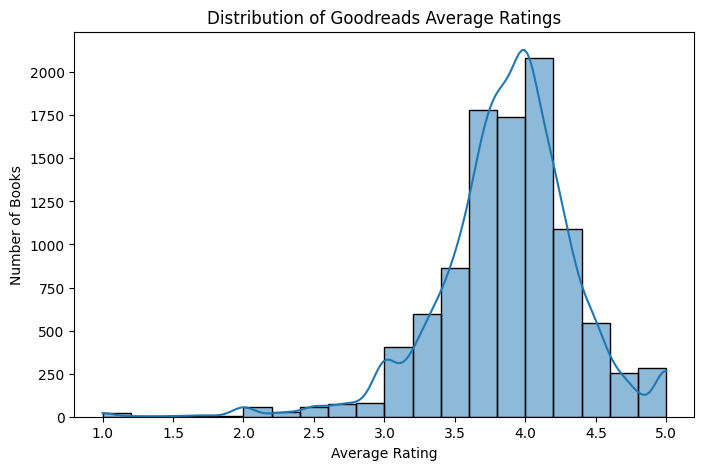

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of average book ratings
plt.figure(figsize=(8, 5))
sns.histplot(rated_books["average_rating"], bins=20, kde=True)

plt.title("Distribution of Goodreads Average Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Number of Books")
plt.show()

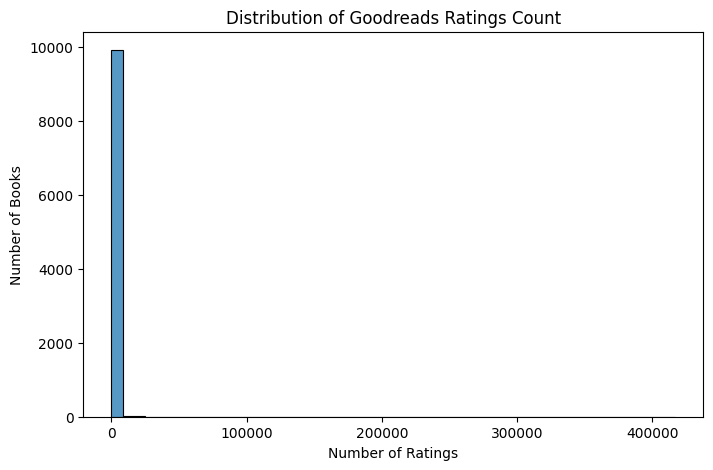

In [23]:
# Distribution of the number of ratings per book

plt.figure(figsize=(8, 5))
sns.histplot(rated_books["ratings_count"], bins=50)

plt.title("Distribution of Goodreads Ratings Count")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Books")
plt.show()

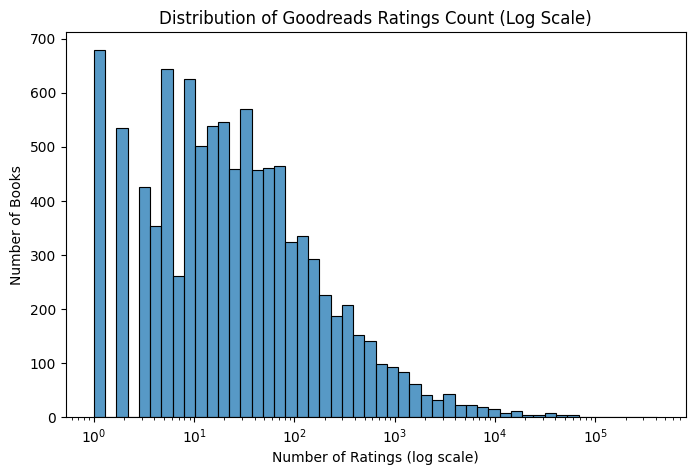

In [24]:
# Plot ratings count on a logarithmic scale to reveal the distribution

plt.figure(figsize=(8, 5))
sns.histplot(rated_books["ratings_count"], bins=50, log_scale=True)

plt.title("Distribution of Goodreads Ratings Count (Log Scale)")
plt.xlabel("Number of Ratings (log scale)")
plt.ylabel("Number of Books")
plt.show()

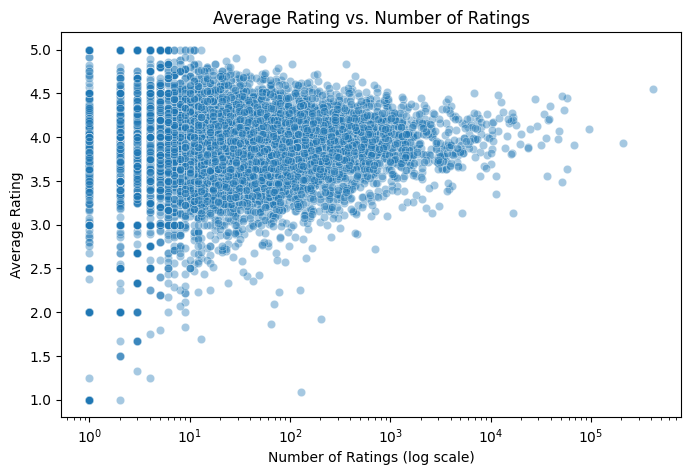

In [25]:
# Relationship between book popularity and average rating

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rated_books,
    x="ratings_count",
    y="average_rating",
    alpha=0.4
)

plt.xscale("log")

plt.title("Average Rating vs. Number of Ratings")
plt.xlabel("Number of Ratings (log scale)")
plt.ylabel("Average Rating")
plt.show()

In [29]:
# Check the distribution of publication years by broad historical ranges

year_ranges = {
    "Before 1000": (sample_df["publication_year"] < 1000).sum(),
    "1000–1799": ((sample_df["publication_year"] >= 1000) &
                  (sample_df["publication_year"] < 1800)).sum(),
    "1800–1899": ((sample_df["publication_year"] >= 1800) &
                  (sample_df["publication_year"] < 1900)).sum(),
    "1900–1999": ((sample_df["publication_year"] >= 1900) &
                  (sample_df["publication_year"] < 2000)).sum(),
    "2000–2019": ((sample_df["publication_year"] >= 2000) &
                  (sample_df["publication_year"] <= 2019)).sum()
}

pd.Series(year_ranges)

,0
Before 1000,6
1000–1799,10
1800–1899,10
1900–1999,1183
2000–2019,6133


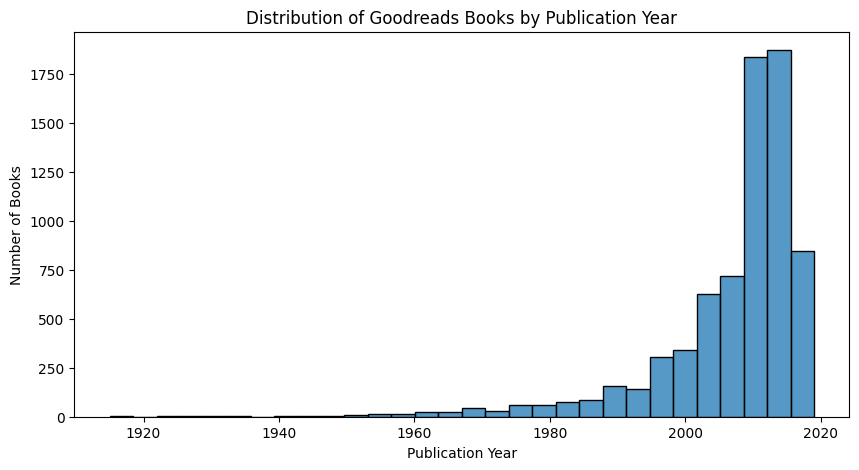

In [31]:
# Distribution of publication years for books published from 1900 onward

year_data = sample_df[
    (sample_df["publication_year"] >= 1900) &
    (sample_df["publication_year"] <= 2020)
]

plt.figure(figsize=(10, 5))

sns.histplot(
    year_data["publication_year"],
    bins=30
)

plt.title("Distribution of Goodreads Books by Publication Year")
plt.xlabel("Publication Year")
plt.ylabel("Number of Books")
plt.show()

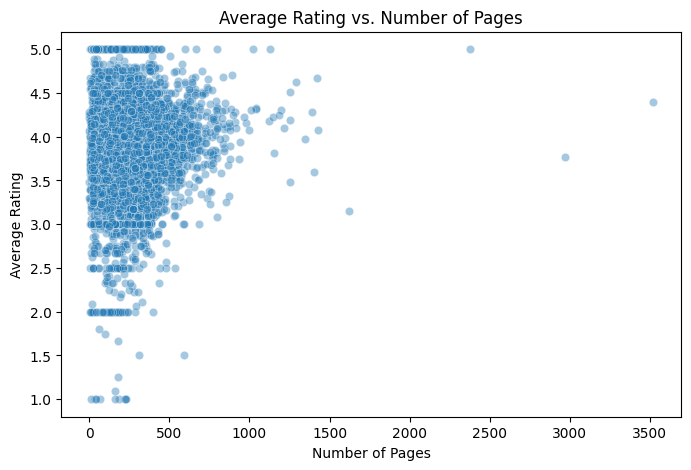

In [32]:
# Relationship between book length and average rating

pages_data = rated_books[
    (rated_books["num_pages"].notna()) &
    (rated_books["num_pages"] > 0)
]

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=pages_data,
    x="num_pages",
    y="average_rating",
    alpha=0.4
)

plt.title("Average Rating vs. Number of Pages")
plt.xlabel("Number of Pages")
plt.ylabel("Average Rating")
plt.show()

In [33]:
# Core variables for EDA and statistical analysis

keep_cols = [
    "book_id",
    "title",
    "average_rating",
    "ratings_count",
    "text_reviews_count",
    "num_pages",
    "publication_year",
    "language_code",
    "format",
    "is_ebook",
    "publisher",
    "authors"
]

In [34]:
import gzip
import json
import pandas as pd

full_rows = []

with gzip.open(path, "rt", encoding="utf-8") as f:
    for line in f:
        book = json.loads(line)

        full_rows.append({
            col: book.get(col)
            for col in keep_cols
        })

full_df = pd.DataFrame(full_rows)

print("Shape:", full_df.shape)
full_df.head()

Shape: (2360655, 12)


,book_id,title,average_rating,ratings_count,text_reviews_count,num_pages,publication_year,language_code,format,is_ebook,publisher,authors
0,5333265,W.C. Fields: A Life on Film,4.00,3,1,256,1984,,Paperback,false,St. Martin's Press,"[{'author_id': '604031', 'role': ''}]"
1,1333909,Good Harbor,3.23,10,6,,2001,,Audio CD,false,Simon & Schuster Audio,"[{'author_id': '626222', 'role': ''}]"
2,7327624,"The Unschooled Wizard (Sun Wolf and Starhawk, ...",4.03,140,7,600,1987,eng,Hardcover,false,"Nelson Doubleday, Inc.","[{'author_id': '10333', 'role': ''}]"
3,6066819,Best Friends Forever,3.49,51184,3282,368,2009,eng,Hardcover,false,Atria Books,"[{'author_id': '9212', 'role': ''}]"
4,287140,Runic Astrology: Starcraft and Timekeeping in ...,3.40,15,5,,,,,false,,"[{'author_id': '149918', 'role': ''}]"


In [35]:
# Convert key analytical variables to numeric values; invalid or empty values become NaN

numeric_cols = [
    "average_rating",
    "ratings_count",
    "text_reviews_count",
    "num_pages",
    "publication_year"
]

for col in numeric_cols:
    full_df[col] = pd.to_numeric(full_df[col], errors="coerce")

In [36]:
# Keep books with a valid rating for rating-based analysis
rated_books = full_df[
    full_df["average_rating"].notna() &
    (full_df["average_rating"] > 0)
].copy()

# Keep books with valid publication years for time-based analysis
year_books = full_df[
    full_df["publication_year"].between(1900, 2019)
].copy()

# Keep books with valid page counts for page-based analysis
pages_books = rated_books[
    rated_books["num_pages"].notna() &
    (rated_books["num_pages"] > 0)
].copy()

print("Total books:", len(full_df))
print("Rated books:", len(rated_books))
print("Valid year books:", len(year_books))
print("Books with valid pages + ratings:", len(pages_books))

Total books: 2360655
Rated books: 2353073
Valid year books: 1757194
Books with valid pages + ratings: 1584735


In [37]:
full_df[numeric_cols].describe()

,average_rating,ratings_count,text_reviews_count,num_pages,publication_year
count,2.360131e+06,2.360131e+06,2.360131e+06,1.596522e+06,1.761030e+06
mean,3.865792e+00,4.063074e+02,2.808668e+01,2.635639e+02,2.007614e+03
std,5.406798e-01,1.112635e+04,3.787806e+02,8.298744e+02,2.480758e+02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.630000e+00,6.000000e+00,2.000000e+00,1.470000e+02,2.004000e+03
50%,3.910000e+00,2.000000e+01,4.000000e+00,2.450000e+02,2.011000e+03
75%,4.160000e+00,7.700000e+01,1.100000e+01,3.440000e+02,2.014000e+03
max,5.000000e+00,4.899965e+06,1.426450e+05,9.450770e+05,6.553500e+04


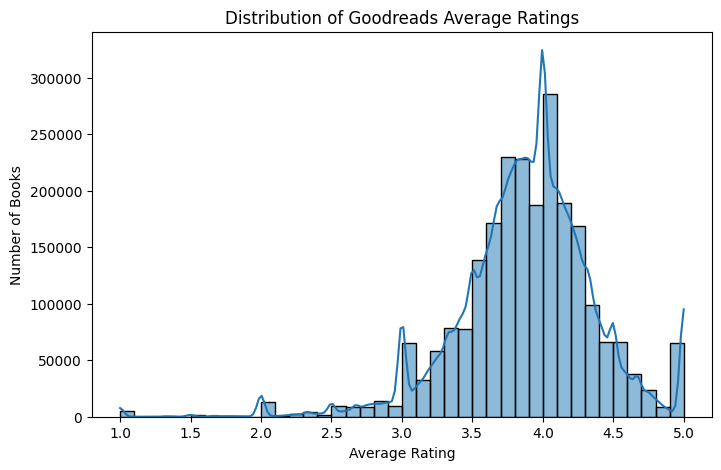

In [38]:
# Distribution of average ratings across all books with valid ratings

plt.figure(figsize=(8, 5))

sns.histplot(
    rated_books["average_rating"],
    bins=40,
    kde=True
)

plt.title("Distribution of Goodreads Average Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Number of Books")

plt.show()

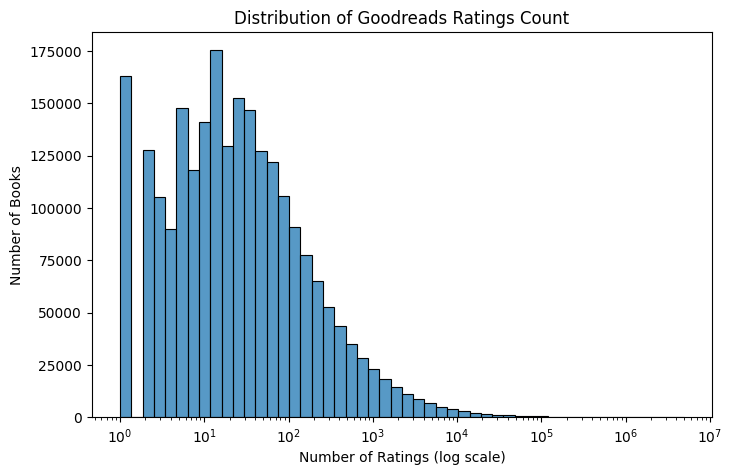

In [39]:
# Distribution of ratings count using a logarithmic x-axis

plt.figure(figsize=(8, 5))

sns.histplot(
    rated_books["ratings_count"],
    bins=50,
    log_scale=True
)

plt.title("Distribution of Goodreads Ratings Count")
plt.xlabel("Number of Ratings (log scale)")
plt.ylabel("Number of Books")

plt.show()

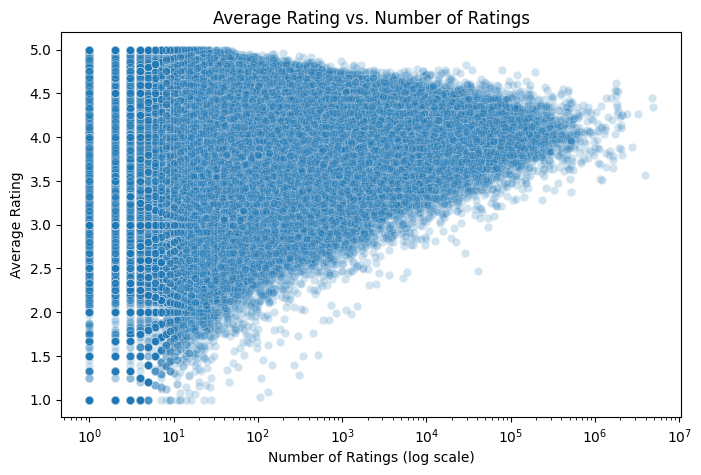

In [40]:
# Relationship between book popularity and average rating

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rated_books,
    x="ratings_count",
    y="average_rating",
    alpha=0.2
)

plt.xscale("log")

plt.title("Average Rating vs. Number of Ratings")
plt.xlabel("Number of Ratings (log scale)")
plt.ylabel("Average Rating")

plt.show()

In [43]:
from scipy.stats import spearmanr

rho, p_value = spearmanr(
    rated_books["ratings_count"],
    rated_books["average_rating"]
)

print("Spearman correlation:", rho)

Spearman correlation: 0.009036387031510789


In [44]:
# Check how many publication years fall into suspicious ranges

year_quality = {
    "Missing": full_df["publication_year"].isna().sum(),
    "Before 1000": (full_df["publication_year"] < 1000).sum(),
    "1000–1799": ((full_df["publication_year"] >= 1000) &
                  (full_df["publication_year"] < 1800)).sum(),
    "1800–1899": ((full_df["publication_year"] >= 1800) &
                  (full_df["publication_year"] < 1900)).sum(),
    "1900–2019": ((full_df["publication_year"] >= 1900) &
                  (full_df["publication_year"] <= 2019)).sum(),
    "After 2019": (full_df["publication_year"] > 2019).sum()
}

pd.Series(year_quality)

,0
Missing,599625
Before 1000,746
1000–1799,1536
1800–1899,1018
1900–2019,1757194
After 2019,536


In [48]:
year_books = full_df[
    full_df["publication_year"].between(1900, 2019)
].copy()

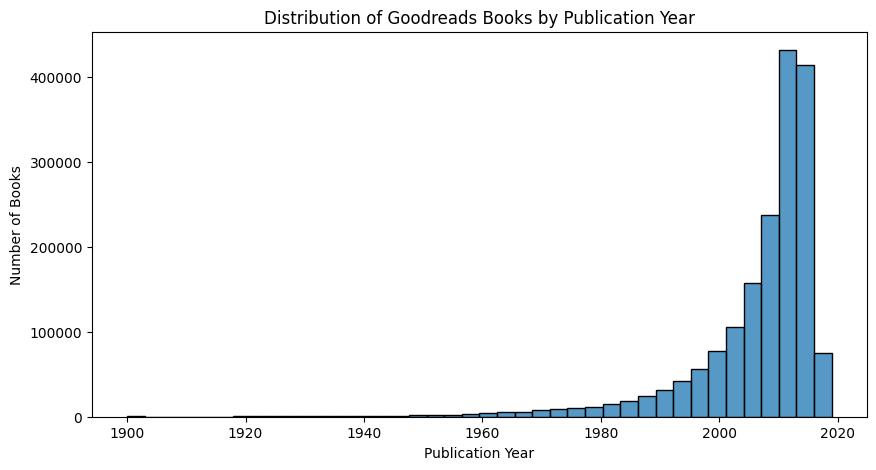

In [49]:
plt.figure(figsize=(10, 5))

sns.histplot(
    year_books["publication_year"],
    bins=40
)

plt.title("Distribution of Goodreads Books by Publication Year")
plt.xlabel("Publication Year")
plt.ylabel("Number of Books")

plt.show()

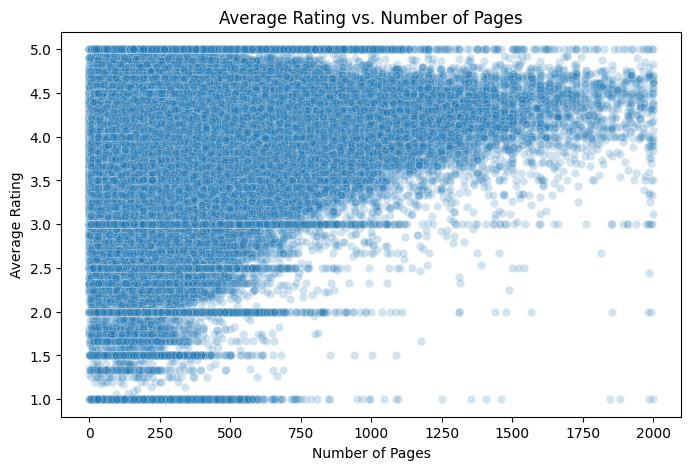

In [51]:
# Relationship between book length and average rating

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=pages_books,
    x="num_pages",
    y="average_rating",
    alpha=0.2
)

plt.title("Average Rating vs. Number of Pages")
plt.xlabel("Number of Pages")
plt.ylabel("Average Rating")

plt.show()

In [52]:
from scipy.stats import spearmanr

rho, p_value = spearmanr(
    pages_books["num_pages"],
    pages_books["average_rating"]
)

print("Spearman correlation:", rho)

Spearman correlation: 0.08137757247047335
